In [1]:
import os
print("当前工作目录:", os.getcwd())

当前工作目录: c:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate


## 一.研究二维颗粒体系

- 这是复现Jamming最简单的2D 模型

### 1.绘制Press-phi曲线

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1、文件路径
file_path_slow_rate = "compress_rate_0.0001/press_phi_compress_rate_0.0001.txt"
file_path_rate_fast_rate  = "compress_rate_0.001/press_phi_compress_rate_0.001.txt"


# 2、读取函数
def load_press_phi(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")

    phi = df["phi"].values
    press = df["press"].values
    # 保证按 phi 从小到大排序
    sort_idx = np.argsort(phi)
    phi = phi[sort_idx]
    press = press[sort_idx]
    
    return phi, press


# 3、读取两组数据
phi_slow, press_slow = load_press_phi(file_path_slow_rate)
phi_fast, press_fast = load_press_phi(file_path_rate_fast_rate)

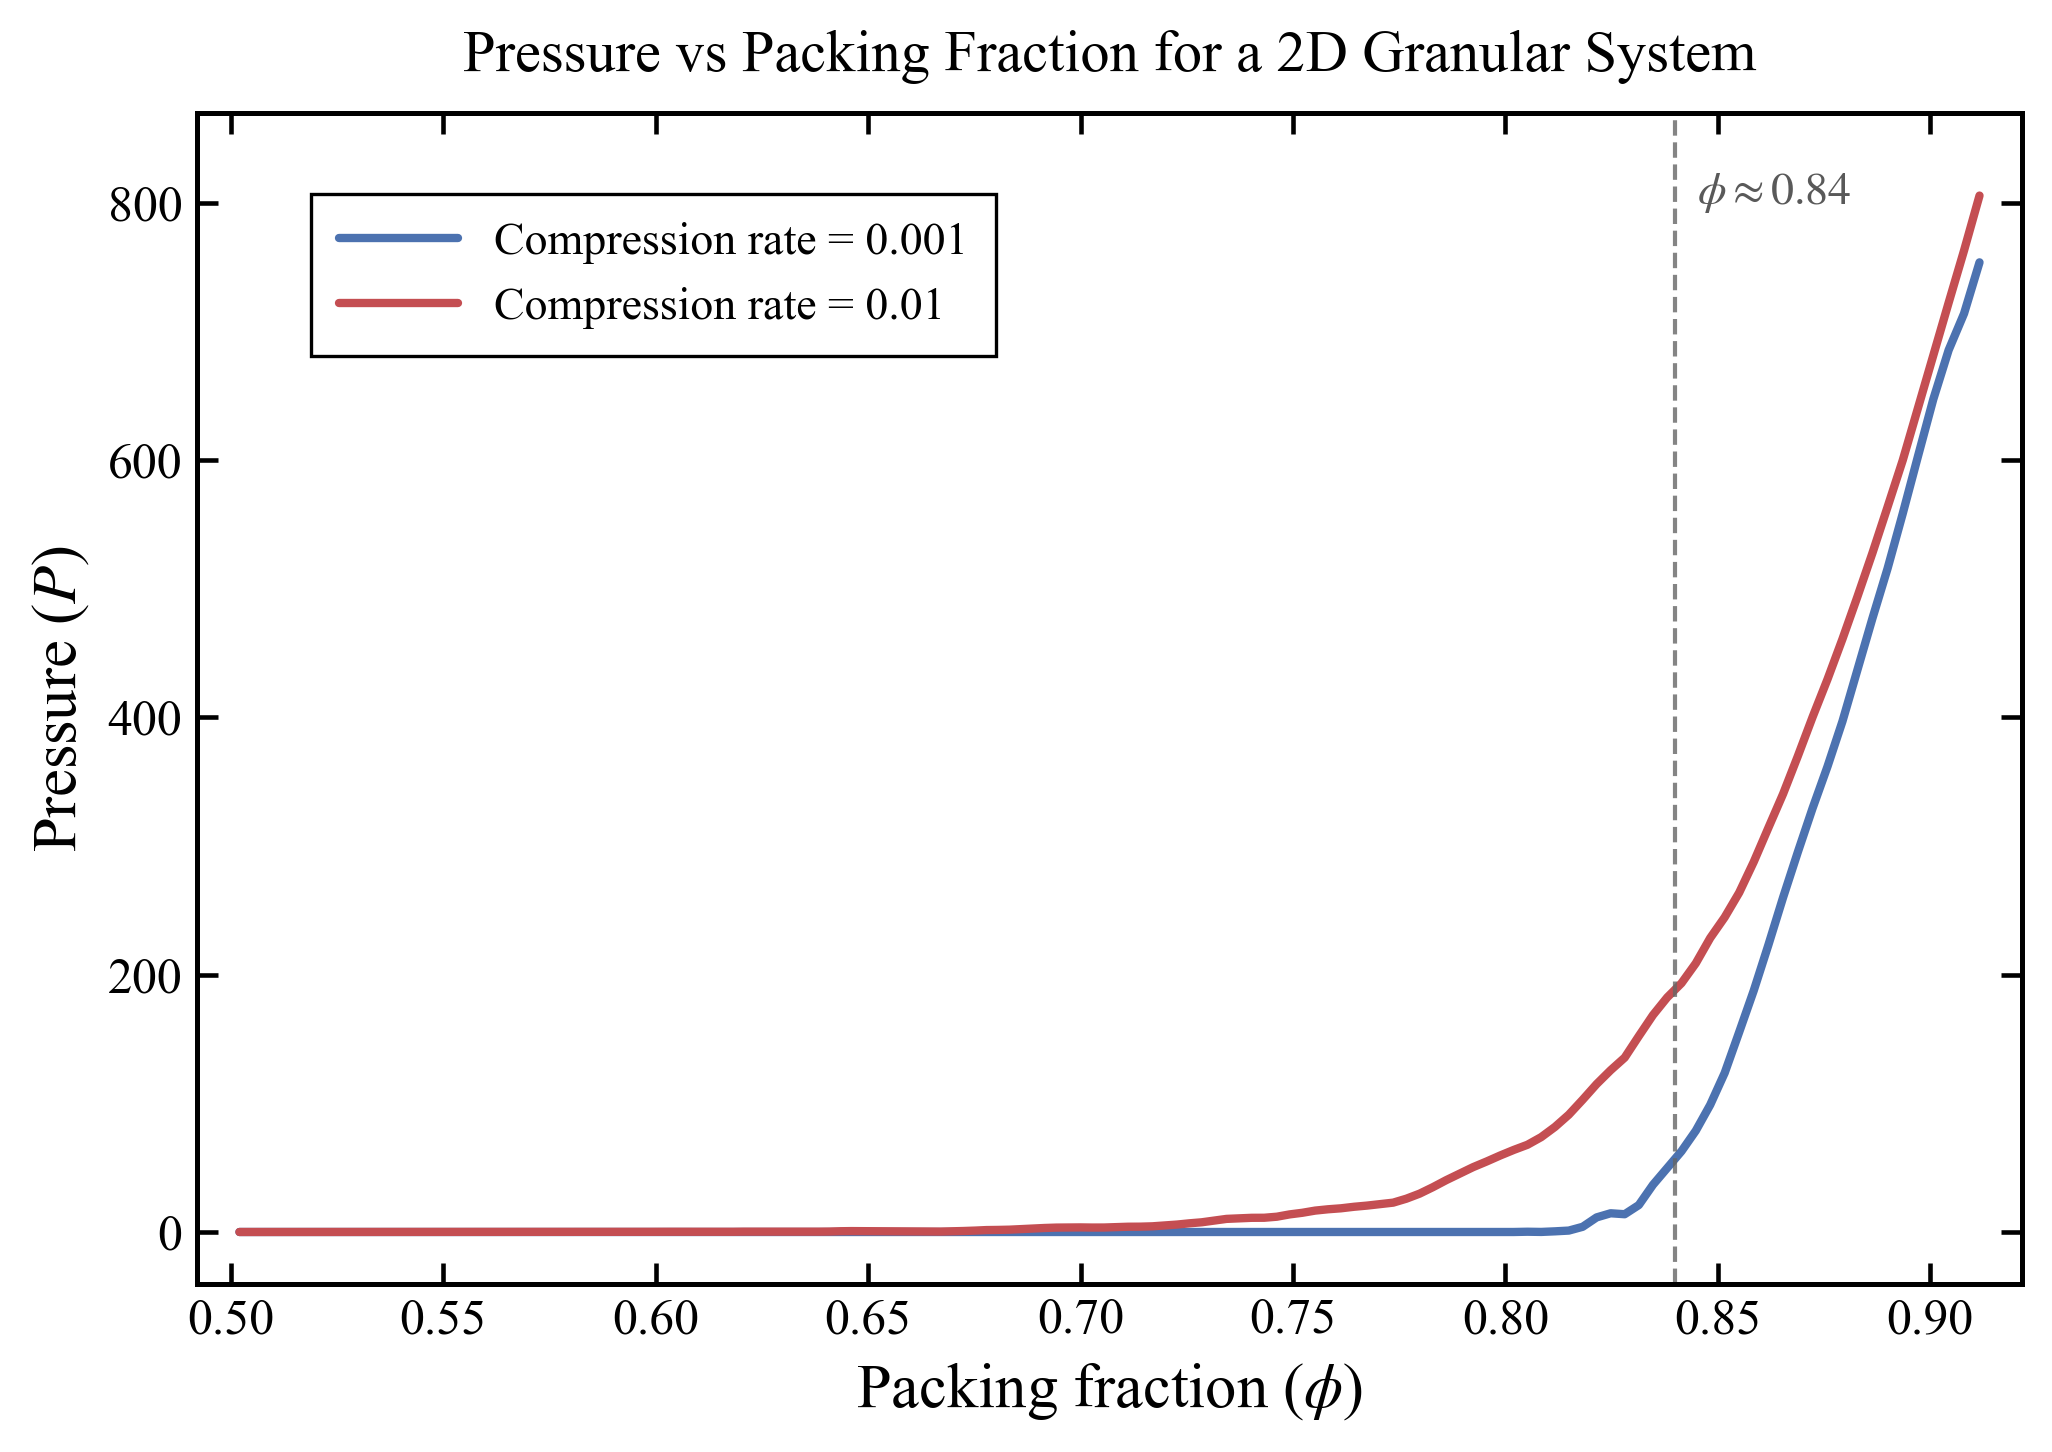

In [2]:
# ========= Nature-like style =========
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2,
})

# ========= muted colors =========
color_slow = "#4C72B0"   # muted blue
color_fast = "#C44E52"   # muted red

# ========= figure =========
fig, ax = plt.subplots(figsize=(7.0, 5.0), dpi=300)

ax.plot(
    phi_slow, press_slow,
    lw=2.0, color=color_slow,
    label=r"Compression rate = 0.001",
    solid_capstyle="round"
)

ax.plot(
    phi_fast, press_fast,
    lw=2.0, color=color_fast,
    label=r"Compression rate = 0.01",
    solid_capstyle="round"
)

# ========= optional reference line =========
phi_j = 0.84
ax.axvline(phi_j, color="0.4", lw=1.0, ls="--", alpha=0.8)
ax.text(
    phi_j + 0.005, 0.95, r"$\phi \approx 0.84$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top", fontsize=11, color="0.35"
)

# ========= axes =========
xmin = min(np.min(phi_slow), np.min(phi_fast))
xmax = max(np.max(phi_slow), np.max(phi_fast))
ymin = min(np.min(press_slow), np.min(press_fast))
ymax = max(np.max(press_slow), np.max(press_fast))

ax.set_xlim(max(0.0, xmin - 0.01), min(1.0, xmax + 0.01))
ax.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.08 * (ymax - ymin))

ax.set_xlabel(r"Packing fraction ($\phi$)")
ax.set_ylabel(r"Pressure ($P$)")

# ========= ticks =========
ax.tick_params(axis="both", which="major", direction="in",
               top=True, right=True, length=5, width=1.1)
ax.tick_params(axis="both", which="minor", direction="in",
               top=True, right=True, length=3, width=0.9)

# ========= legend with paper-style frame =========
leg = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.05, 0.95),  # 👈 往里挪
    frameon=True,         # 打开边框
    fancybox=False,       # 直角框，更像论文
    framealpha=1.0,       # 不透明
    edgecolor="black",    # 黑色边框
    handlelength=2.6,
    borderpad=0.6
)
leg.get_frame().set_linewidth(0.8)   # 边框细一点，更像论文
leg.get_frame().set_facecolor("white")

# ========= spines =========
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")

ax.set_title("Pressure vs Packing Fraction for a 2D Granular System", pad=10)

plt.tight_layout()
plt.savefig("compress_rate_0.001/pressure_phi_curves.png", dpi=600, bbox_inches="tight")
plt.show()

### 2.绘制RDF曲线

In [3]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录


from utils.compute_rdf import compute_rdf_fn
from utils.draw_rdf import draw_rdf_fn

In [4]:
# 计算compress_rate=0.001下的RDF曲线
INPUT_FILE = "compress_rate_0.001/traj_compress_rate_0.001.xyz"
OUTPUT_DIR = "compress_rate_0.001/rdf_output"

compute_rdf_fn(INPUT_FILE=INPUT_FILE, OUTPUT_DIR=OUTPUT_DIR, START_FRAME=1)

[INFO] Input trajectory : compress_rate_0.001\traj_compress_rate_0.001.xyz
[INFO] Output directory : C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\rdf_output
[INFO] R_MAX = 10.0, DR = 0.02
[INFO] Saved frame 1, timestep = 0
[INFO] Saved frame 2, timestep = 5000
[INFO] Saved frame 3, timestep = 10000
[INFO] Saved frame 4, timestep = 15000
[INFO] Saved frame 5, timestep = 20000
[INFO] Saved frame 6, timestep = 25000
[INFO] Saved frame 7, timestep = 30000
[INFO] Saved frame 8, timestep = 35000
[INFO] Saved frame 9, timestep = 40000
[INFO] Saved frame 10, timestep = 45000
[INFO] Saved frame 11, timestep = 50000
[INFO] Saved frame 12, timestep = 55000
[INFO] Saved frame 13, timestep = 60000
[INFO] Saved frame 14, timestep = 65000
[INFO] Saved frame 15, timestep = 70000
[INFO] Saved frame 16, timestep = 75000
[INFO] Saved frame 17, timestep = 80000
[INFO] Saved frame 18, timestep = 85000
[INFO] Saved frame 19, timestep = 90000
[INFO] Saved frame 

[DONE] Figure saved to: compress_rate_0.001/rdf_compare.png


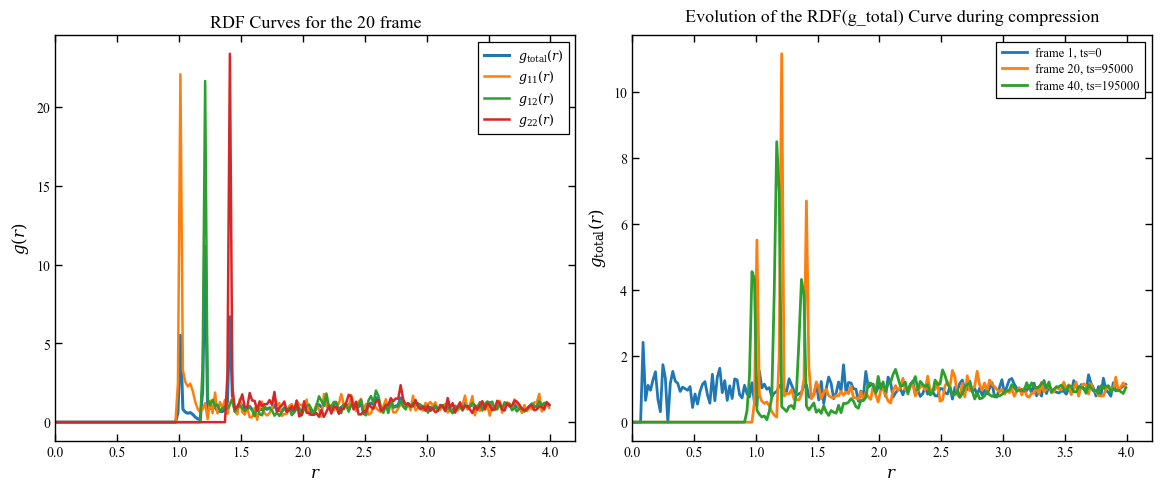

In [5]:
rdf_dir = "compress_rate_0.001/rdf_output"
save_fig_path = "compress_rate_0.001/rdf_compare.png"

single_frame = 20
compare_frames = [1, 20, 40]
compare_column = "g_total"   # 可选: g_total, g11, g12, g22


# 这是utils写好的函数, 直接按要求调用即可
draw_rdf_fn(RDF_DIR = rdf_dir, 
            SAVE_FIG_PATH = save_fig_path,
            SINGLE_FRAME = single_frame, 
            COMPARE_FRAMES = compare_frames,
            COMPARE_COLUMN = compare_column)

### 3.绘制tau-phi曲线

In [6]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录

from utils.compute_tau import compute_tau_fn, draw_tau_fn

=============== Parameter Info ===================
[INFO] D             : 1.0
[INFO] R_MAX         : 10.0
[INFO] SCALE         : 0.998
[DONE] Saved all-frame tau data to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\all_frames_tau.csv
[DONE] Figure saved to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\pictures\tau_phi_curve.png


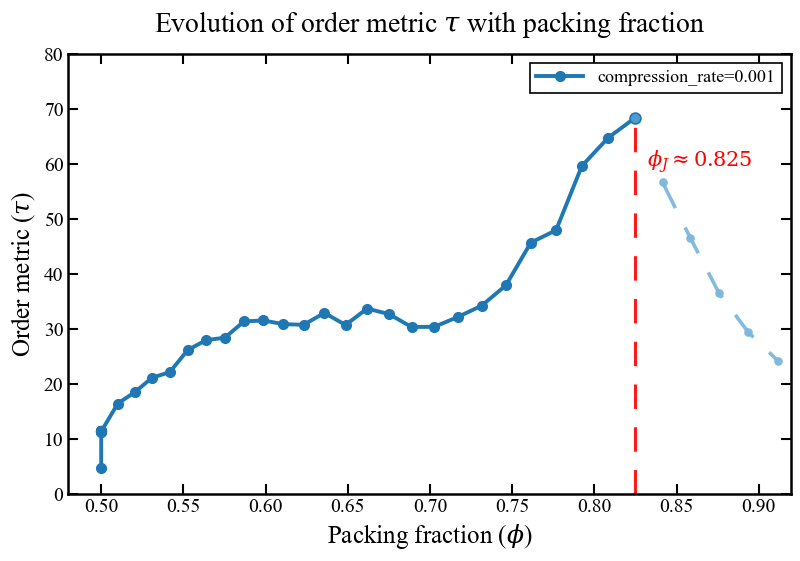

In [7]:
rdf_dir = "compress_rate_0.001/rdf_output"
output_csv = "compress_rate_0.001/all_frames_tau.csv"
g_column = "g_total"     # 可选: g_total, g11, g12, g22
save_fig_path = "compress_rate_0.001/pictures/tau_phi_curve.png"


# 1.从单个压缩实验中读取rdf_dir目录下的所有文件,然后计算出一个tau-phi值
compute_tau_fn(RDF_DIR=rdf_dir, OUTPUT_CSV=output_csv, G_COLUMN=g_column)

# 2.绘制对应的tau-phi曲线图
draw_tau_fn(INPUT_CSV=output_csv, SAVE_FIG=save_fig_path)

 - 值得注意的是: 在本次实验中, phi_j=0.825(而不是0.844),原因有两方面:
    - 涨落影响: 只是计算了单个实验中的体系变化, 而0.844是统计下的理论值
    - 有限压缩速率: 本实验压缩速率为0.001, 达不到FIRE能量最小化的效果

### 4.绘制z-phi曲线

In [8]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录

from utils.compute_z import compute_z_distribution_fn, draw_z_distribution_fn

[INFO] Input trajectory : compress_rate_0.001\traj_compress_rate_0.001.xyz
[INFO] Output directory : C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\z_output
[INFO] CONTACT_TOL = 0.001
[DONE] Total processed frames: 41
[DONE] Figure saved to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\pictures\z_distribution_multi_frames.png


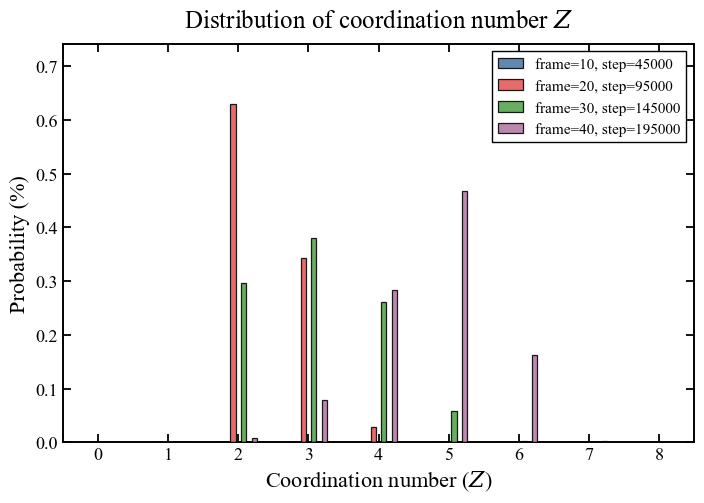

In [9]:
# 给出输入、输出路径
input_file = "compress_rate_0.001/traj_compress_rate_0.001.xyz"
output_dir = "compress_rate_0.001/z_output"
save_fig_path = "compress_rate_0.001/pictures/z_distribution_multi_frames.png"


compute_z_distribution_fn(
    INPUT_FILE=input_file,
    OUTPUT_DIR=output_dir ,
    START_FRAME=1
)


# 多帧对比
draw_z_distribution_fn(
    INPUT_DIR=output_dir,
    FRAME_LIST=[10, 20, 30, 40],
    SAVE_FIG=save_fig_path
)